
# 📧 SMS Spam Message Classifier using Machine Learning

### Developed by: Gopi Krishnan

### Technologies Used
- Python
- Google Colab
- Pandas
- Scikit-learn
- CountVectorizer
- Logistic Regression

## 🎯 Project Objective

The objective of this project is to develop an intelligent SMS Spam Message Classifier using supervised machine learning techniques. The model automatically classifies SMS messages as **Spam** or **Ham (Normal)** by converting text into numerical features using Natural Language Processing (NLP). Logistic Regression was selected as the final model after comparing multiple feature extraction techniques and classification algorithms.

In [2]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [3]:
# Load Dataset

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

data = pd.read_csv(url, sep='\t', header=None, names=["label", "message"])

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 🔍 Explore Dataset

In [4]:
# Display first five rows

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
# Check for missing values

data.isnull().sum()

,0
label,0
message,0


In [7]:
# Number of Spam and Ham messages

data["label"].value_counts()

,count
label,
ham,4825
spam,747


## 🧹 Data Preprocessing

In [8]:
# Separate features and target

X = data["message"]
y = data["label"]

print("Features (X):")
print(X.head())

print("\nLabels (y):")
print(y.head())

Features (X):
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: object

Labels (y):
0     ham
1     ham
2    spam
3     ham
4     ham
Name: label, dtype: object


## 🔤 Feature Extraction using CountVectorizer

In [9]:
# Convert text into numerical features

vectorizer = CountVectorizer()

X_vectorized = vectorizer.fit_transform(X)

print("Shape of Feature Matrix:", X_vectorized.shape)

Shape of Feature Matrix: (5572, 8713)


## ✂️ Split Dataset into Training and Testing Sets

In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4457, 8713)
Testing Data Shape: (1115, 8713)


## 🧠 Train Logistic Regression Model

In [11]:
# Create and train the Logistic Regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 📊 Model Evaluation

In [12]:
# Make predictions on the test data

y_pred = model.predict(X_test)

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 98.83%


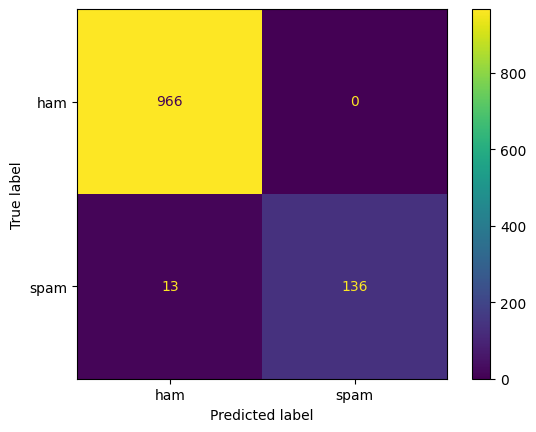

In [13]:
# Display Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

display.plot()
plt.show()

In [14]:
# Print Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       1.00      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



## 📩 Test the Model with Custom Messages

In [15]:
# Enter your own SMS message

message = ["Congratulations! You have won a free iPhone. Click here to claim now."]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

print("Prediction:", prediction[0])

Prediction: spam


## 🎯 Prediction Confidence

In [16]:
# Predict probabilities

probability = model.predict_proba(message_vector)

print("Ham Probability :", probability[0][0])
print("Spam Probability:", probability[0][1])

Ham Probability : 0.20764189357121854
Spam Probability: 0.7923581064287815


## 📈 Dataset Visualization

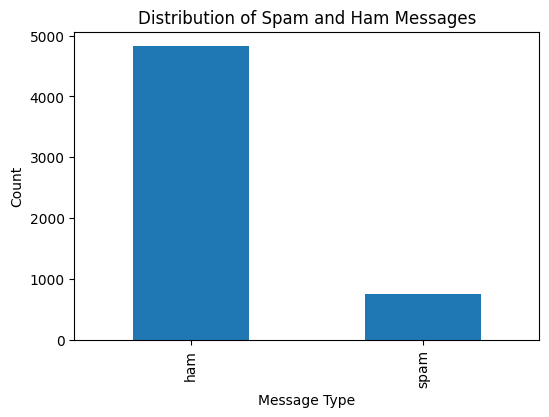

In [18]:
# Visualize Spam vs Ham Messages

data["label"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution of Spam and Ham Messages"
)

plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

## 🏆 Results

- Feature Extraction Technique: **CountVectorizer**
- Machine Learning Algorithm: **Logistic Regression**
- Test Accuracy: **98.83%**
- The model successfully classifies SMS messages as Spam or Ham with high accuracy.

# 📋 Project Summary

| Feature | Description |
|---------|-------------|
| Project | SMS Spam Message Classifier |
| Domain | Natural Language Processing (NLP) |
| Algorithm | Logistic Regression |
| Feature Extraction | CountVectorizer |
| Dataset | SMS Spam Collection |
| Accuracy | **98.83%** |
| Language | Python |
| Libraries | Pandas, Scikit-learn, Matplotlib |

## ✅ Conclusion

In this project, an SMS Spam Classifier was developed using Natural Language Processing (NLP) and Machine Learning. SMS messages were converted into numerical features using CountVectorizer, and a Logistic Regression model was trained to classify messages as Spam or Ham.

The final model achieved an accuracy of approximately **98.83%**, demonstrating excellent performance on unseen data. This project highlights the effectiveness of combining text preprocessing techniques with supervised machine learning for real-world spam detection.